In [1]:
# Mount google drive
from google.colab import drive
drive.mount("/content/drive")

Mounted at /content/drive


In [2]:
# Path of directory
drive_path = "/content/drive/MyDrive"
root_path = f"{drive_path}/master/mxene-solvent-nrc/code-data/dataset/"

In [3]:
import pandas as pd

In [4]:
# Load data
df_mx_solvent_data_labeled = pd.read_pickle(f"{root_path}/dataset_mx_solvent_hsp.pkl")
df_mx_solvent_data_labeled.columns = df_mx_solvent_data_labeled.columns.str.lower()
print(df_mx_solvent_data_labeled.shape)
df_mx_solvent_data_labeled.head()

(997, 65)


,mx,label,inchikey,gap_oh,work_function_oh,formation_energy_oh,ehull_oh,alphax_el_oh,alphay_el_oh,alphaz_el_oh,...,isotope_atom_count,atom_stereo_count,bond_stereo_count,covalent_unit_count,boiling_point,mmhg,solvent,method_hf,method_licl/hf,method_lif/hcl
0,Ti3C2,1,XLYOFNOQVPJJNP-UHFFFAOYSA-N,0.0,1.985656,-1.294839,0.123329,32.369286,32.369286,1.474909,...,0,0,0,1,373.2,760.0,oxidane,True,False,False
1,Ti3C2,1,LFQSCWFLJHTTHZ-UHFFFAOYSA-N,0.0,1.985656,-1.294839,0.123329,32.369286,32.369286,1.474909,...,0,0,0,1,351.5,760.0,ethanol,True,False,False
2,Ti3C2,-1,OKKJLVBELUTLKV-UHFFFAOYSA-N,0.0,1.985656,-1.294839,0.123329,32.369286,32.369286,1.474909,...,0,0,0,1,337.8,760.0,methanol,True,False,False
3,Ti3C2,-1,CSCPPACGZOOCGX-UHFFFAOYSA-N,0.0,1.985656,-1.294839,0.123329,32.369286,32.369286,1.474909,...,0,0,0,1,329.3,760.0,propan-2-one,True,False,False
4,Ti3C2,-1,WEVYAHXRMPXWCK-UHFFFAOYSA-N,0.0,1.985656,-1.294839,0.123329,32.369286,32.369286,1.474909,...,0,0,0,1,354.8,760.0,acetonitrile,True,False,False


In [5]:
cols_to_keep = [col for col in df_mx_solvent_data_labeled.columns if not (df_mx_solvent_data_labeled[col].nunique() <= 1)]
df_mx_solvent_data_labeled = df_mx_solvent_data_labeled[cols_to_keep]

In [6]:
import numpy as np
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split, GridSearchCV, RandomizedSearchCV
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report

In [7]:
df_mx_solvent_data_labeled['method_hf'] = df_mx_solvent_data_labeled['method_hf'].astype('category').cat.codes
df_mx_solvent_data_labeled['method_licl/hf'] = df_mx_solvent_data_labeled['method_licl/hf'].astype('category').cat.codes
df_mx_solvent_data_labeled['method_lif/hcl'] = df_mx_solvent_data_labeled['method_lif/hcl'].astype('category').cat.codes

In [8]:
df_mx_solvent_data_labeled.head()

,mx,label,inchikey,work_function_oh,formation_energy_oh,ehull_oh,alphax_el_oh,alphay_el_oh,alphaz_el_oh,plasmafrequency_x_oh,...,h_bond_donor_count,h_bond_acceptor_count,rotatable_bond_count,heavy_atom_count,atom_stereo_count,boiling_point,solvent,method_hf,method_licl/hf,method_lif/hcl
0,Ti3C2,1,XLYOFNOQVPJJNP-UHFFFAOYSA-N,1.985656,-1.294839,0.123329,32.369286,32.369286,1.474909,5.064378,...,1,1,0,1,0,373.2,oxidane,1,0,0
1,Ti3C2,1,LFQSCWFLJHTTHZ-UHFFFAOYSA-N,1.985656,-1.294839,0.123329,32.369286,32.369286,1.474909,5.064378,...,1,1,0,3,0,351.5,ethanol,1,0,0
2,Ti3C2,-1,OKKJLVBELUTLKV-UHFFFAOYSA-N,1.985656,-1.294839,0.123329,32.369286,32.369286,1.474909,5.064378,...,1,1,0,2,0,337.8,methanol,1,0,0
3,Ti3C2,-1,CSCPPACGZOOCGX-UHFFFAOYSA-N,1.985656,-1.294839,0.123329,32.369286,32.369286,1.474909,5.064378,...,0,1,0,4,0,329.3,propan-2-one,1,0,0
4,Ti3C2,-1,WEVYAHXRMPXWCK-UHFFFAOYSA-N,1.985656,-1.294839,0.123329,32.369286,32.369286,1.474909,5.064378,...,0,1,0,3,0,354.8,acetonitrile,1,0,0


In [9]:
df_mx_solvent_data_labeled.columns

Index(['mx', 'label', 'inchikey', 'work_function_oh', 'formation_energy_oh',
       'ehull_oh', 'alphax_el_oh', 'alphay_el_oh', 'alphaz_el_oh',
       'plasmafrequency_x_oh', 'plasmafrequency_y_oh',
       'has_inversion_symmetry_oh', 'gap_o', 'work_function_o',
       'formation_energy_o', 'ehull_o', 'alphax_el_o', 'alphay_el_o',
       'alphaz_el_o', 'plasmafrequency_x_o', 'plasmafrequency_y_o',
       'has_inversion_symmetry_o', 'work_function_f', 'formation_energy_f',
       'ehull_f', 'alphax_el_f', 'alphay_el_f', 'alphaz_el_f',
       'plasmafrequency_x_f', 'plasmafrequency_y_f',
       'has_inversion_symmetry_f', 'delta_d', 'delta_p', 'delta_h',
       'molar_volume', 'molecular_weight', 'xlogp', 'tpsa', 'complexity',
       'h_bond_donor_count', 'h_bond_acceptor_count', 'rotatable_bond_count',
       'heavy_atom_count', 'atom_stereo_count', 'boiling_point', 'solvent',
       'method_hf', 'method_licl/hf', 'method_lif/hcl'],
      dtype='object')

In [10]:
features = ['work_function_oh', 'formation_energy_oh',
       'ehull_oh', 'alphax_el_oh', 'alphay_el_oh', 'alphaz_el_oh',
       'plasmafrequency_x_oh', 'plasmafrequency_y_oh',
       'has_inversion_symmetry_oh', 'gap_o', 'work_function_o',
       'formation_energy_o', 'ehull_o', 'alphax_el_o', 'alphay_el_o',
       'alphaz_el_o', 'plasmafrequency_x_o', 'plasmafrequency_y_o',
       'has_inversion_symmetry_o', 'work_function_f', 'formation_energy_f',
       'ehull_f', 'alphax_el_f', 'alphay_el_f', 'alphaz_el_f',
       'plasmafrequency_x_f', 'plasmafrequency_y_f',
       'has_inversion_symmetry_f', 'delta_d', 'delta_p', 'delta_h',
       'molar_volume',
       'molecular_weight', 'xlogp', 'tpsa', 'complexity', 'h_bond_donor_count',
       'h_bond_acceptor_count', 'rotatable_bond_count', 'heavy_atom_count',
       'atom_stereo_count', 'boiling_point', 'method_hf',
       'method_licl/hf', 'method_lif/hcl']
X = df_mx_solvent_data_labeled[features]
y = df_mx_solvent_data_labeled['label']

In [11]:
X.head()

,work_function_oh,formation_energy_oh,ehull_oh,alphax_el_oh,alphay_el_oh,alphaz_el_oh,plasmafrequency_x_oh,plasmafrequency_y_oh,has_inversion_symmetry_oh,gap_o,...,complexity,h_bond_donor_count,h_bond_acceptor_count,rotatable_bond_count,heavy_atom_count,atom_stereo_count,boiling_point,method_hf,method_licl/hf,method_lif/hcl
0,1.985656,-1.294839,0.123329,32.369286,32.369286,1.474909,5.064378,5.064378,0,0.477608,...,0.0,1,1,0,1,0,373.2,1,0,0
1,1.985656,-1.294839,0.123329,32.369286,32.369286,1.474909,5.064378,5.064378,0,0.477608,...,2.8,1,1,0,3,0,351.5,1,0,0
2,1.985656,-1.294839,0.123329,32.369286,32.369286,1.474909,5.064378,5.064378,0,0.477608,...,2.0,1,1,0,2,0,337.8,1,0,0
3,1.985656,-1.294839,0.123329,32.369286,32.369286,1.474909,5.064378,5.064378,0,0.477608,...,26.3,0,1,0,4,0,329.3,1,0,0
4,1.985656,-1.294839,0.123329,32.369286,32.369286,1.474909,5.064378,5.064378,0,0.477608,...,29.3,0,1,0,3,0,354.8,1,0,0


In [12]:
y.head()

,label
0,1
1,1
2,-1
3,-1
4,-1


In [13]:
import matplotlib.pyplot as plt
import seaborn as sns

In [14]:
mask_pos = y == 1
mask_neg = y == -1
mask_unlabeled = y == 0


In [18]:
X[mask_neg].shape


(39, 45)

In [16]:
X[mask_pos].shape

(44, 45)

In [19]:
X_train = X[mask_pos | mask_neg]
y_train = y[mask_pos | mask_neg]

In [20]:
X_test = X[mask_unlabeled]
df_unlabeled = df_mx_solvent_data_labeled[mask_unlabeled].copy()

In [21]:
X_train_train, X_val, y_train_train, y_val = train_test_split(X_train, y_train, test_size=0.2, random_state=42, stratify=y_train)

In [22]:
print(len(X_train_train))
print(len(X_val))
print(len(y_train_train))
print(len(y_val))

66
17
66
17


In [23]:
from sklearn.ensemble import BaggingClassifier
from sklearn.metrics import accuracy_score

In [24]:
param_grid = {
    'n_estimators': [10, 25, 100],
    'max_samples': [0.8, 1.0]
}

In [25]:
base_rf = RandomForestClassifier(random_state=42)
bagging_clf = BaggingClassifier(estimator=base_rf, random_state=42)

In [26]:
rand_search = RandomizedSearchCV(bagging_clf, param_grid, cv=5, n_jobs=1, scoring='accuracy', verbose=2)
rand_search.fit(X_train_train, y_train_train)


/usr/local/lib/python3.12/dist-packages/sklearn/model_selection/_search.py:317: UserWarning: The total space of parameters 6 is smaller than n_iter=10. Running 6 iterations. For exhaustive searches, use GridSearchCV.
  warnings.warn(


Fitting 5 folds for each of 6 candidates, totalling 30 fits
[CV] END ...................max_samples=0.8, n_estimators=10; total time=   1.5s
[CV] END ...................max_samples=0.8, n_estimators=10; total time=   1.5s
[CV] END ...................max_samples=0.8, n_estimators=10; total time=   1.5s
[CV] END ...................max_samples=0.8, n_estimators=10; total time=   1.5s
[CV] END ...................max_samples=0.8, n_estimators=10; total time=   2.2s
[CV] END ...................max_samples=0.8, n_estimators=25; total time=   4.4s
[CV] END ...................max_samples=0.8, n_estimators=25; total time=   3.7s
[CV] END ...................max_samples=0.8, n_estimators=25; total time=   3.6s
[CV] END ...................max_samples=0.8, n_estimators=25; total time=   5.2s
[CV] END ...................max_samples=0.8, n_estimators=25; total time=   3.6s
[CV] END ..................max_samples=0.8, n_estimators=100; total time=  16.3s
[CV] END ..................max_samples=0.8, n_est

RandomizedSearchCV(cv=5,
                   estimator=BaggingClassifier(estimator=RandomForestClassifier(random_state=42),
                                               random_state=42),
                   n_jobs=1,
                   param_distributions={'max_samples': [0.8, 1.0],
                                        'n_estimators': [10, 25, 100]},
                   scoring='accuracy', verbose=2)

In [27]:
best_model = rand_search.best_estimator_
print(best_model)

BaggingClassifier(estimator=RandomForestClassifier(random_state=42),
                  max_samples=0.8, random_state=42)


In [28]:
y_train_pred = best_model.predict(X_train)
y_val_pred = best_model.predict(X_val)

print("Train Accuracy:", accuracy_score(y_train, y_train_pred))
print("Val Accuracy:", accuracy_score(y_val, y_val_pred))
print("Validation Report:\n", classification_report(y_val, y_val_pred))

Train Accuracy: 0.9518072289156626
Val Accuracy: 0.8823529411764706
Validation Report:
               precision    recall  f1-score   support

          -1       0.80      1.00      0.89         8
           1       1.00      0.78      0.88         9

    accuracy                           0.88        17
   macro avg       0.90      0.89      0.88        17
weighted avg       0.91      0.88      0.88        17



In [29]:
proba_unlabeled = best_model.predict_proba(X_test)[:, 1]  # Probability of class 1 (positive)
df_unlabeled['predicted_proba'] = proba_unlabeled
df_unlabeled['predicted_label'] = (proba_unlabeled >= 0.5).astype(int)

In [30]:
import matplotlib.pyplot as plt
import seaborn as sns

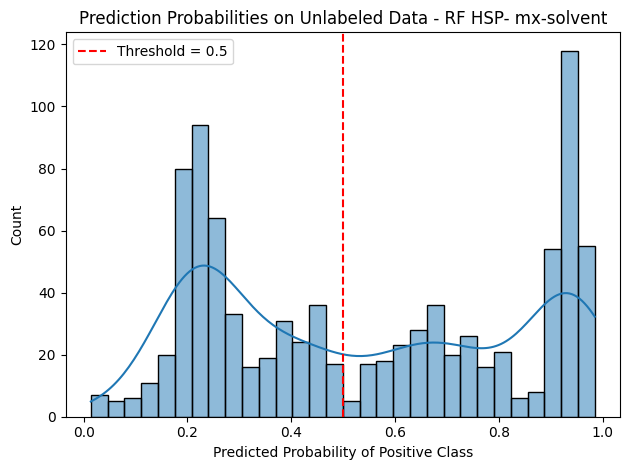

In [31]:
sns.histplot(proba_unlabeled, bins=30, kde=True)
plt.axvline(0.5, color='red', linestyle='--', label='Threshold = 0.5')
plt.title("Prediction Probabilities on Unlabeled Data - RF HSP- mx-solvent")
plt.xlabel("Predicted Probability of Positive Class")
plt.ylabel("Count")
plt.legend()
plt.tight_layout()
plt.show()

In [32]:
high_conf = df_unlabeled[df_unlabeled['predicted_proba'] >= 0.9]
top_10 = high_conf.sort_values(by='predicted_proba', ascending=False).head(20)
print(top_10[['solvent', 'mx', 'predicted_proba', 'method_lif/hcl', 'method_licl/hf', 'method_hf']])

                      solvent     mx  predicted_proba  method_lif/hcl  \
190     methylsulfinylmethane  Nb2C1            0.985               1   
676     methylsulfinylmethane  Zr3C2            0.984               1   
514     methylsulfinylmethane  Ti2C1            0.983               0   
800  1-methylpyrrolidin-2-one   V4C3            0.983               1   
434  1-methylpyrrolidin-2-one  Mo2C1            0.983               1   
432     methylsulfinylmethane  Mo2C1            0.983               1   
922  1-methylpyrrolidin-2-one  Ta4C3            0.982               1   
920     methylsulfinylmethane  Ta4C3            0.982               1   
393  1-methylpyrrolidin-2-one  Mo2C1            0.981               0   
272  1-methylpyrrolidin-2-one   V2C1            0.981               0   
150     methylsulfinylmethane  Nb2C1            0.981               0   
311     methylsulfinylmethane   V2C1            0.981               1   
798     methylsulfinylmethane   V4C3            0.9

In [33]:
low_conf = df_unlabeled[df_unlabeled['predicted_proba'] <= 0.1]
bottom_10 = low_conf.sort_values(by='predicted_proba', ascending=True).head(20)

print("MXene-solvent pairs predicted to NOT work at all (P ≤ 0.1):")
print(bottom_10[['mx', 'solvent','predicted_proba', 'method_lif/hcl', 'method_licl/hf', 'method_hf']])

MXene-solvent pairs predicted to NOT work at all (P ≤ 0.1):
        mx                                     solvent  predicted_proba  \
141  Ti3C2                               chlorobenzene            0.014   
108  Ti3C2                               chlorobenzene            0.020   
88   Ti3C2                                  1,4-xylene            0.023   
131  Ti3C2                                     heptane            0.025   
98   Ti3C2                                     heptane            0.028   
87   Ti3C2                                 cyclohexane            0.032   
86   Ti3C2                                  chloroform            0.046   
130  Ti3C2                          tetrachloromethane            0.047   
97   Ti3C2                          tetrachloromethane            0.055   
144  Ti3C2                                     styrene            0.064   
111  Ti3C2                                     styrene            0.072   
119  Ti3C2                         1,2-d

In [34]:
df_unlabeled.columns

Index(['mx', 'label', 'inchikey', 'work_function_oh', 'formation_energy_oh',
       'ehull_oh', 'alphax_el_oh', 'alphay_el_oh', 'alphaz_el_oh',
       'plasmafrequency_x_oh', 'plasmafrequency_y_oh',
       'has_inversion_symmetry_oh', 'gap_o', 'work_function_o',
       'formation_energy_o', 'ehull_o', 'alphax_el_o', 'alphay_el_o',
       'alphaz_el_o', 'plasmafrequency_x_o', 'plasmafrequency_y_o',
       'has_inversion_symmetry_o', 'work_function_f', 'formation_energy_f',
       'ehull_f', 'alphax_el_f', 'alphay_el_f', 'alphaz_el_f',
       'plasmafrequency_x_f', 'plasmafrequency_y_f',
       'has_inversion_symmetry_f', 'delta_d', 'delta_p', 'delta_h',
       'molar_volume', 'molecular_weight', 'xlogp', 'tpsa', 'complexity',
       'h_bond_donor_count', 'h_bond_acceptor_count', 'rotatable_bond_count',
       'heavy_atom_count', 'atom_stereo_count', 'boiling_point', 'solvent',
       'method_hf', 'method_licl/hf', 'method_lif/hcl', 'predicted_proba',
       'predicted_label'],
      dty

In [35]:
print("\n=== Summary of predicted probabilities on unlabeled data ===")
print(df_unlabeled['predicted_proba'].describe())

# Count how many samples fall into different confidence zones
bins = [0.0, 0.1, 0.3, 0.5, 0.7, 0.9, 1.0]
labels = ['Very Low (≤0.1)', 'Low (0.1–0.3)', 'Mid (0.3–0.5)',
          'High (0.5–0.7)', 'Very High (0.7–0.9)', 'Extremely High (>0.9)']

df_unlabeled['confidence_bin'] = pd.cut(df_unlabeled['predicted_proba'], bins=bins, labels=labels, include_lowest=True)
print("\n=== Prediction count by confidence bin ===")
print(df_unlabeled['confidence_bin'].value_counts().sort_index())


=== Summary of predicted probabilities on unlabeled data ===
count    914.000000
mean       0.539489
std        0.298081
min        0.014000
25%        0.242000
50%        0.488000
75%        0.883750
max        0.985000
Name: predicted_proba, dtype: float64

=== Prediction count by confidence bin ===
confidence_bin
Very Low (≤0.1)           18
Low (0.1–0.3)            296
Mid (0.3–0.5)            149
High (0.5–0.7)           132
Very High (0.7–0.9)       97
Extremely High (>0.9)    222
Name: count, dtype: int64


In [36]:
df_unlabeled.columns

Index(['mx', 'label', 'inchikey', 'work_function_oh', 'formation_energy_oh',
       'ehull_oh', 'alphax_el_oh', 'alphay_el_oh', 'alphaz_el_oh',
       'plasmafrequency_x_oh', 'plasmafrequency_y_oh',
       'has_inversion_symmetry_oh', 'gap_o', 'work_function_o',
       'formation_energy_o', 'ehull_o', 'alphax_el_o', 'alphay_el_o',
       'alphaz_el_o', 'plasmafrequency_x_o', 'plasmafrequency_y_o',
       'has_inversion_symmetry_o', 'work_function_f', 'formation_energy_f',
       'ehull_f', 'alphax_el_f', 'alphay_el_f', 'alphaz_el_f',
       'plasmafrequency_x_f', 'plasmafrequency_y_f',
       'has_inversion_symmetry_f', 'delta_d', 'delta_p', 'delta_h',
       'molar_volume', 'molecular_weight', 'xlogp', 'tpsa', 'complexity',
       'h_bond_donor_count', 'h_bond_acceptor_count', 'rotatable_bond_count',
       'heavy_atom_count', 'atom_stereo_count', 'boiling_point', 'solvent',
       'method_hf', 'method_licl/hf', 'method_lif/hcl', 'predicted_proba',
       'predicted_label', 'confidenc

In [37]:
train_path = f"{drive_path}/master/mxene-solvent-nrc/code-data/training/final/hsp/"

In [38]:
df_unlabeled.to_csv(f"{train_path}/002_p_vs_n_predictions_unlabeled_rf-normalize-fintune-mxsolv.csv")
df_unlabeled.to_pickle(f"{train_path}/002_p_vs_n_predictions_unlabeled_rf-normalize-fintune-mxsolv.pkl")


                  feature  importance
30                delta_h    0.137248
33                  xlogp    0.130601
34                   tpsa    0.114923
29                delta_p    0.103392
41          boiling_point    0.093382
31           molar_volume    0.063519
28                delta_d    0.061078
37  h_bond_acceptor_count    0.055196
32       molecular_weight    0.052147
35             complexity    0.048726


/tmp/ipython-input-3827308663.py:17: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='importance', y='feature', data=feature_importance_df.head(10), palette='viridis')


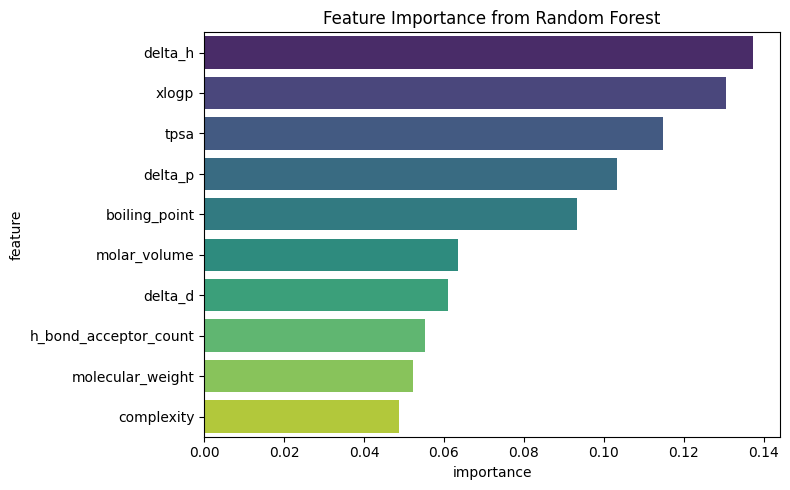

In [39]:
feature_names = X.columns

# Later, after training
importances = np.array([tree.feature_importances_ for tree in best_model.estimators_])
mean_importance = np.mean(importances, axis=0)

# Use saved feature_names directly
feature_importance_df = pd.DataFrame({
    'feature': feature_names,
    'importance': mean_importance
}).sort_values(by='importance', ascending=False)

print(feature_importance_df.head(10))

# Plot
plt.figure(figsize=(8, 5))
sns.barplot(x='importance', y='feature', data=feature_importance_df.head(10), palette='viridis')
plt.title('Feature Importance from Random Forest')
plt.tight_layout()
plt.show()

In [40]:
mx_features = ['work_function_oh', 'formation_energy_oh', 'ehull_oh', 'alphax_el_oh',
       'alphay_el_oh', 'alphaz_el_oh', 'plasmafrequency_x_oh',
       'plasmafrequency_y_oh', 'has_inversion_symmetry_oh', 'gap_o',
       'work_function_o', 'formation_energy_o', 'ehull_o', 'alphax_el_o',
       'alphay_el_o', 'alphaz_el_o', 'plasmafrequency_x_o',
       'plasmafrequency_y_o', 'has_inversion_symmetry_o', 'work_function_f',
       'formation_energy_f', 'ehull_f', 'alphax_el_f', 'alphay_el_f',
       'alphaz_el_f', 'plasmafrequency_x_f', 'plasmafrequency_y_f',
       'has_inversion_symmetry_f']
solv_features = ['delta_d', 'delta_p', 'delta_h',
       'molar_volume', 'boiling_point', 'molecular_weight', 'xlogp', 'tpsa', 'complexity', 'h_bond_donor_count',
       'h_bond_acceptor_count', 'rotatable_bond_count', 'heavy_atom_count',
       'atom_stereo_count']
# add_features = ['molecular_weight_additive', 'xlogp_additive', 'tpsa_additive',
      #  'complexity_additive', 'h_bond_donor_count_additive',
      #  'h_bond_acceptor_count_additive', 'rotatable_bond_count_additive',
      #  'heavy_atom_count_additive', 'atom_stereo_count_additive',
      #  'bond_stereo_count_additive', 'covalent_unit_count_additive']



In [41]:
top_mx = feature_importance_df[feature_importance_df['feature'].isin(mx_features)] \
            .sort_values(by='importance', ascending=False) \
            .head(5)

# Top 5 from Solvent features
top_solv = feature_importance_df[feature_importance_df['feature'].isin(solv_features)] \
              .sort_values(by='importance', ascending=False) \
              .head(5)

# top_add = feature_importance_df[feature_importance_df['feature'].isin(add_features)] \
#               .sort_values(by='importance', ascending=False) \
#               .head(5)

# Display
print("Total  MXene Features:", len(mx_features))
print("Top 5 MXene Features:")
print(top_mx.to_string(index=False))

print("\nTotal  Solvent Features:", len(solv_features))
print("Top 5 Solvent Features:")
print(top_solv.to_string(index=False))

# print("\nTotal  Additive Features:", len(add_features))
# print("Top 5 Additive Features:")
# print(top_solv.to_string(index=False))

Total  MXene Features: 28
Top 5 MXene Features:
             feature  importance
plasmafrequency_y_oh    0.006172
            ehull_oh    0.004492
plasmafrequency_x_oh    0.004437
        alphax_el_oh    0.004230
        alphay_el_oh    0.002875

Total  Solvent Features: 14
Top 5 Solvent Features:
      feature  importance
      delta_h    0.137248
        xlogp    0.130601
         tpsa    0.114923
      delta_p    0.103392
boiling_point    0.093382


In [42]:
num_unique_mx = df_unlabeled["mx"].nunique()

print("Number of unique MXenes:", num_unique_mx)

Number of unique MXenes: 8


In [43]:
df_unlabeled.columns

Index(['mx', 'label', 'inchikey', 'work_function_oh', 'formation_energy_oh',
       'ehull_oh', 'alphax_el_oh', 'alphay_el_oh', 'alphaz_el_oh',
       'plasmafrequency_x_oh', 'plasmafrequency_y_oh',
       'has_inversion_symmetry_oh', 'gap_o', 'work_function_o',
       'formation_energy_o', 'ehull_o', 'alphax_el_o', 'alphay_el_o',
       'alphaz_el_o', 'plasmafrequency_x_o', 'plasmafrequency_y_o',
       'has_inversion_symmetry_o', 'work_function_f', 'formation_energy_f',
       'ehull_f', 'alphax_el_f', 'alphay_el_f', 'alphaz_el_f',
       'plasmafrequency_x_f', 'plasmafrequency_y_f',
       'has_inversion_symmetry_f', 'delta_d', 'delta_p', 'delta_h',
       'molar_volume', 'molecular_weight', 'xlogp', 'tpsa', 'complexity',
       'h_bond_donor_count', 'h_bond_acceptor_count', 'rotatable_bond_count',
       'heavy_atom_count', 'atom_stereo_count', 'boiling_point', 'solvent',
       'method_hf', 'method_licl/hf', 'method_lif/hcl', 'predicted_proba',
       'predicted_label', 'confidenc

In [44]:
import pandas as pd

# Assuming df has columns: ['mx', 'solvent', 'probability']
top_solvents = (
    df_unlabeled
    .sort_values("predicted_proba", ascending=False)
    .drop_duplicates(subset=["mx", "solvent"])   # avoid duplicate solvents per MXene
    .groupby("mx")
    .head(5)
    [
        ["mx", "solvent", "predicted_proba",
         "method_lif/hcl", "method_licl/hf", "method_hf"]
    ]
    .reset_index(drop=True)
)

print(top_solvents)

       mx                   solvent  predicted_proba  method_lif/hcl  \
0   Nb2C1     methylsulfinylmethane            0.985               1   
1   Zr3C2     methylsulfinylmethane            0.984               1   
2   Ti2C1     methylsulfinylmethane            0.983               0   
3    V4C3  1-methylpyrrolidin-2-one            0.983               1   
4   Mo2C1  1-methylpyrrolidin-2-one            0.983               1   
5   Mo2C1     methylsulfinylmethane            0.983               1   
6   Ta4C3  1-methylpyrrolidin-2-one            0.982               1   
7   Ta4C3     methylsulfinylmethane            0.982               1   
8    V2C1  1-methylpyrrolidin-2-one            0.981               0   
9    V4C3     methylsulfinylmethane            0.981               1   
10   V2C1     methylsulfinylmethane            0.981               1   
11  Ti2C1  1-methylpyrrolidin-2-one            0.979               1   
12  Nb2C1  1-methylpyrrolidin-2-one            0.979            

In [45]:
df_train = df_mx_solvent_data_labeled[mask_pos | mask_neg].copy()
df_train

,mx,label,inchikey,work_function_oh,formation_energy_oh,ehull_oh,alphax_el_oh,alphay_el_oh,alphaz_el_oh,plasmafrequency_x_oh,...,h_bond_donor_count,h_bond_acceptor_count,rotatable_bond_count,heavy_atom_count,atom_stereo_count,boiling_point,solvent,method_hf,method_licl/hf,method_lif/hcl
0,Ti3C2,1,XLYOFNOQVPJJNP-UHFFFAOYSA-N,1.985656,-1.294839,0.123329,32.369286,32.369286,1.474909,5.064378,...,1,1,0,1,0,373.2,oxidane,1,0,0
1,Ti3C2,1,LFQSCWFLJHTTHZ-UHFFFAOYSA-N,1.985656,-1.294839,0.123329,32.369286,32.369286,1.474909,5.064378,...,1,1,0,3,0,351.5,ethanol,1,0,0
2,Ti3C2,-1,OKKJLVBELUTLKV-UHFFFAOYSA-N,1.985656,-1.294839,0.123329,32.369286,32.369286,1.474909,5.064378,...,1,1,0,2,0,337.8,methanol,1,0,0
3,Ti3C2,-1,CSCPPACGZOOCGX-UHFFFAOYSA-N,1.985656,-1.294839,0.123329,32.369286,32.369286,1.474909,5.064378,...,0,1,0,4,0,329.3,propan-2-one,1,0,0
4,Ti3C2,-1,WEVYAHXRMPXWCK-UHFFFAOYSA-N,1.985656,-1.294839,0.123329,32.369286,32.369286,1.474909,5.064378,...,0,1,0,3,0,354.8,acetonitrile,1,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
78,Ti3C2,-1,MVPPADPHJFYWMZ-UHFFFAOYSA-N,1.985656,-1.294839,0.123329,32.369286,32.369286,1.474909,5.064378,...,0,0,0,7,0,404.9,chlorobenzene,0,0,1
79,Ti3C2,1,AMQJEAYHLZJPGS-UHFFFAOYSA-N,1.985656,-1.294839,0.123329,32.369286,32.369286,1.474909,5.064378,...,1,1,3,6,0,411.0,pentan-1-ol,0,0,1
80,Ti3C2,-1,YNAVUWVOSKDBBP-UHFFFAOYSA-N,1.985656,-1.294839,0.123329,32.369286,32.369286,1.474909,5.064378,...,1,2,0,6,0,401.6,morpholine,0,0,1
81,Ti3C2,1,RUOJZAUFBMNUDX-UHFFFAOYSA-N,1.985656,-1.294839,0.123329,32.369286,32.369286,1.474909,5.064378,...,0,3,0,7,1,513.2,"4-methyl-1,3-dioxolan-2-one",0,0,1


In [46]:
proba_train = best_model.predict_proba(X_train)[:, 1]

df_train['predicted_proba'] = proba_train
df_train['predicted_label'] = (proba_train >= 0.5).astype(int)

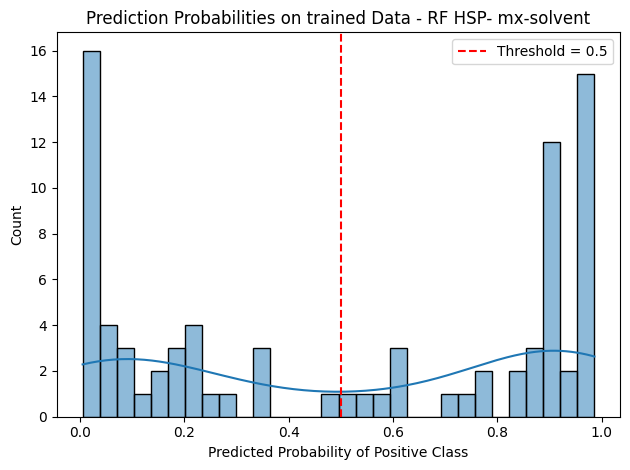

In [47]:
sns.histplot(proba_train, bins=30, kde=True)
plt.axvline(0.5, color='red', linestyle='--', label='Threshold = 0.5')
plt.title("Prediction Probabilities on trained Data - RF HSP- mx-solvent")
plt.xlabel("Predicted Probability of Positive Class")
plt.ylabel("Count")
plt.legend()
plt.tight_layout()
plt.show()

In [48]:
high_conf_train = df_train[df_train['predicted_proba'] >= 0.9]
top_10_train = high_conf_train.sort_values(by='predicted_proba', ascending=False).head(20)
print(top_10_train[['solvent', 'mx', 'predicted_proba', 'method_lif/hcl', 'method_licl/hf', 'method_hf']])

                        solvent     mx  predicted_proba  method_lif/hcl  \
39        methylsulfinylmethane  Ti2C1            0.986               1   
37     1-methylpyrrolidin-2-one   V2C1            0.984               1   
35     1-methylpyrrolidin-2-one  Nb2C1            0.982               0   
42     1-methylpyrrolidin-2-one   V4C3            0.981               0   
36     1-methylpyrrolidin-2-one  Nb2C1            0.980               1   
50        methylsulfinylmethane  Ti3C2            0.973               1   
17        methylsulfinylmethane  Ti3C2            0.973               1   
43                      ethanol  Ta4C3            0.966               0   
28        methylsulfinylmethane  Ti3C2            0.965               0   
19     1-methylpyrrolidin-2-one  Ti3C2            0.963               1   
53     1-methylpyrrolidin-2-one  Ti3C2            0.963               1   
5         methylsulfinylmethane  Ti3C2            0.961               0   
45     1-methylpyrrolidin

In [49]:
top_solvents_train = (
    df_train
    .sort_values("predicted_proba", ascending=False)
    .drop_duplicates(subset=["mx", "solvent"])   # keep best solvent per mx
    .groupby("mx")
    .head(30)
    [["mx", "solvent", "predicted_proba", 'method_lif/hcl', 'method_licl/hf', 'method_hf']]
    .reset_index(drop=True)
)

print(top_solvents_train)

       mx                                     solvent  predicted_proba  \
0   Ti2C1                       methylsulfinylmethane            0.986   
1    V2C1                    1-methylpyrrolidin-2-one            0.984   
2   Nb2C1                    1-methylpyrrolidin-2-one            0.982   
3    V4C3                    1-methylpyrrolidin-2-one            0.981   
4   Ti3C2                       methylsulfinylmethane            0.973   
5   Ta4C3                                     ethanol            0.966   
6   Ti3C2                    1-methylpyrrolidin-2-one            0.963   
7   Zr3C2                                     ethanol            0.957   
8   Mo2C1                                     oxidane            0.940   
9   Ti3C2                       N,N-dimethylacetamide            0.922   
10  Ti3C2                                oxolan-2-one            0.916   
11  Ti3C2                                     ethanol            0.916   
12  Ti3C2                 4-methyl-1,3

In [50]:
green_solvents = [
    "oxidane",
    "ethanol",
    "propan-2-ol",
    "ethyl acetate",
    "methyl acetate"
]

top_solvents_testgreen = (
    df_unlabeled
    .query("predicted_proba < 0.999")
    .query("predicted_proba > 0.5")
    .query("solvent in @green_solvents")   # 👈 GREEN FILTER HERE
    .sort_values("predicted_proba", ascending=False)
    .drop_duplicates(subset=["mx", "solvent"])
    .groupby("mx")
    .head(20)
    [
        ["mx", "solvent", "predicted_proba",
         "method_lif/hcl", "method_licl/hf", "method_hf"]
    ]
    .reset_index(drop=True)
)

print(top_solvents_testgreen)

       mx        solvent  predicted_proba  method_lif/hcl  method_licl/hf  \
0   Mo2C1        ethanol            0.967               0               0   
1    V4C3        ethanol            0.963               0               0   
2    V2C1        ethanol            0.960               0               0   
3   Nb2C1        ethanol            0.959               0               0   
4   Zr3C2        ethanol            0.957               0               1   
5   Ta4C3        ethanol            0.957               0               1   
6   Ti2C1        ethanol            0.956               0               0   
7   Mo2C1        oxidane            0.930               0               1   
8    V4C3        oxidane            0.929               0               0   
9   Ta4C3        oxidane            0.926               0               0   
10   V2C1        oxidane            0.921               0               0   
11  Nb2C1        oxidane            0.908               0               0   

In [51]:
top_solvents_train_green = (
    df_train
    .query("solvent in @green_solvents")
    .sort_values("predicted_proba", ascending=False)
    .drop_duplicates(subset=["mx", "solvent"])   # keep best solvent per mx
    .groupby("mx")
    .head(30)
    [["mx", "solvent", "predicted_proba", 'method_lif/hcl', 'method_licl/hf', 'method_hf']]
    .reset_index(drop=True)
)

print(top_solvents_train_green)

      mx        solvent  predicted_proba  method_lif/hcl  method_licl/hf  \
0  Ta4C3        ethanol            0.966               0               0   
1  Zr3C2        ethanol            0.957               0               0   
2  Mo2C1        oxidane            0.940               0               0   
3  Ti3C2        ethanol            0.916               0               1   
4  Ti3C2        oxidane            0.836               0               1   
5  Ti3C2    propan-2-ol            0.693               1               0   
6  Ti3C2  ethyl acetate            0.482               1               0   

   method_hf  
0          1  
1          1  
2          1  
3          0  
4          0  
5          0  
6          0  


In [52]:
acceptable_solvents = [
    "methanol",
    "acetonitrile",
    "oxolane",
    "hexan-1-ol",
    "4-methyl-1,3-dioxolan-2-one",
    "1-methylpyrrolidin-2-one",
    "methylsulfinylmethane",
    "butyl 2-hydroxypropanoate",
    "cyclohexane"
]

top_solvents_test2_acceptable = (
    df_unlabeled
    .query("predicted_proba < 0.999")
    .query("predicted_proba > 0.5")
    .query("solvent in @acceptable_solvents")   # 👈 ACCEPTABLE FILTER
    .sort_values("predicted_proba", ascending=False)
    .drop_duplicates(subset=["mx", "solvent"])
    .groupby("mx")
    .head(20)
    [
        ["mx", "solvent", "predicted_proba",
         "method_lif/hcl", "method_licl/hf", "method_hf"]
    ]
    .reset_index(drop=True)
)

print(top_solvents_test2_acceptable)

       mx                      solvent  predicted_proba  method_lif/hcl  \
0   Nb2C1        methylsulfinylmethane            0.985               1   
1   Zr3C2        methylsulfinylmethane            0.984               1   
2    V4C3     1-methylpyrrolidin-2-one            0.983               1   
3   Mo2C1     1-methylpyrrolidin-2-one            0.983               1   
4   Ti2C1        methylsulfinylmethane            0.983               0   
5   Mo2C1        methylsulfinylmethane            0.983               1   
6   Ta4C3     1-methylpyrrolidin-2-one            0.982               1   
7   Ta4C3        methylsulfinylmethane            0.982               1   
8    V2C1     1-methylpyrrolidin-2-one            0.981               0   
9    V2C1        methylsulfinylmethane            0.981               1   
10   V4C3        methylsulfinylmethane            0.981               1   
11  Ti2C1     1-methylpyrrolidin-2-one            0.979               1   
12  Nb2C1     1-methylpyr

In [53]:
top_solvents_train_acceptable = (
    df_train
    .query("solvent in @acceptable_solvents")
    .sort_values("predicted_proba", ascending=False)
    .drop_duplicates(subset=["mx", "solvent"])   # keep best solvent per mx
    .groupby("mx")
    .head(30)
    [["mx", "solvent", "predicted_proba", 'method_lif/hcl', 'method_licl/hf', 'method_hf']]
    .reset_index(drop=True)
)

print(top_solvents_train_acceptable)

       mx                      solvent  predicted_proba  method_lif/hcl  \
0   Ti2C1        methylsulfinylmethane            0.986               1   
1    V2C1     1-methylpyrrolidin-2-one            0.984               1   
2   Nb2C1     1-methylpyrrolidin-2-one            0.982               0   
3    V4C3     1-methylpyrrolidin-2-one            0.981               0   
4   Ti3C2        methylsulfinylmethane            0.973               1   
5   Ti3C2     1-methylpyrrolidin-2-one            0.963               1   
6   Ti3C2  4-methyl-1,3-dioxolan-2-one            0.915               1   
7    V2C1                     methanol            0.607               0   
8   Ti3C2                 acetonitrile            0.361               0   
9   Ti3C2                      oxolane            0.258               1   
10  Ti3C2                     methanol            0.223               0   
11  Ti3C2                  cyclohexane            0.024               0   

    method_licl/hf  meth